In [1]:
import numpy as np
from matplotlib import pyplot as plot, cm
from mpl_toolkits.mplot3d import Axes3D

In [2]:
# variables declaration

domain = 2
nx = ny = 41
nt = 12
c = 1
dx = domain / (nx - 1)
dy = domain / (ny - 1)
mu = 0.01
sigma = 0.2         # recall sigma = dt/dx
dt = sigma * dx

u = np.ones((nx, ny))
v = np.ones((nx, ny))

u[int(0.5/dx):int((1/dx)+1),int(0.5/dy):int((1/dy)+1)] = 2
v[int(0.5/dx):int((1/dx)+1),int(0.5/dy):int((1/dy)+1)] = 2

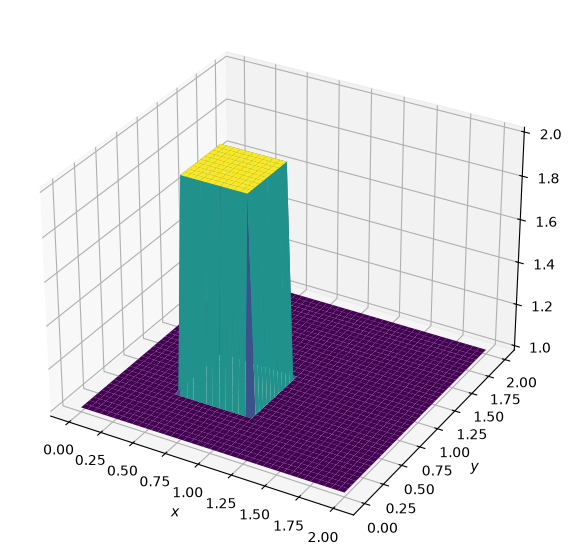

In [3]:
# defining x_grid and y_grid

x = np.linspace(0, domain, nx)
y = np.linspace(0, domain, ny)

# plotting

fig = plot.figure(figsize = (11,7), dpi=100)
ax = fig.add_subplot(111, projection='3d')
# The '111' means a grid of 1 row and 1 column and this subplot is the first one.

X, Y = np.meshgrid(x,y)

surf = ax.plot_surface(X,Y,u,cmap=cm.viridis)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$');

In [4]:
# discretizated equations and looping

for n in range(nt):
    un = u.copy()
    vn = v.copy()
    u[1:-1,1:-1] =( un[1:-1,1:-1] 
             - un[1:-1,1:-1] * (dt/dx) * (un[1:-1,1:-1] - un[:-2,1:-1])
             - vn[1:-1,1:-1] * (dt/dy) * (un[1:-1,1:-1] - un[1:-1,:-2])
             + mu * (dt/(dx)**2) * (un[:-2,1:-1] - 2*un[1:-1,1:-1] + un[2:,1:-1])
             + mu * (dt/(dy)**2) * (un[1:-1,:-2] - 2*un[1:-1,1:-1] + un[1:-1,2:]) )
    v[1:-1,1:-1] =( vn[1:-1,1:-1]
             - un[1:-1,1:-1] * (dt/dx) * (vn[1:-1,1:-1] - vn[:-2,1:-1])
             - vn[1:-1,1:-1] * (dt/dy) * (vn[1:-1,1:-1] - vn[1:-1,:-2])
             + mu * (dt/(dx)**2) * (vn[:-2,1:-1] - 2*vn[1:-1,1:-1] + vn[2:,1:-1])
             + mu * (dt/(dy)**2) * (vn[1:-1,:-2] - 2*vn[1:-1,1:-1] + vn[1:-1,2:]) )
    
    u[0,:] = v[0,:] = 1
    u[-1,:] = v[-1,:] = 1
    u[:,0] = v[:,0] = 1
    u[:,-1] = v[:,-1] = 1

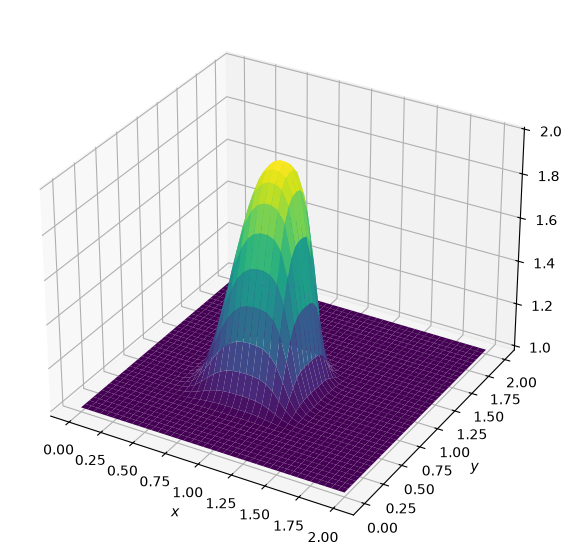

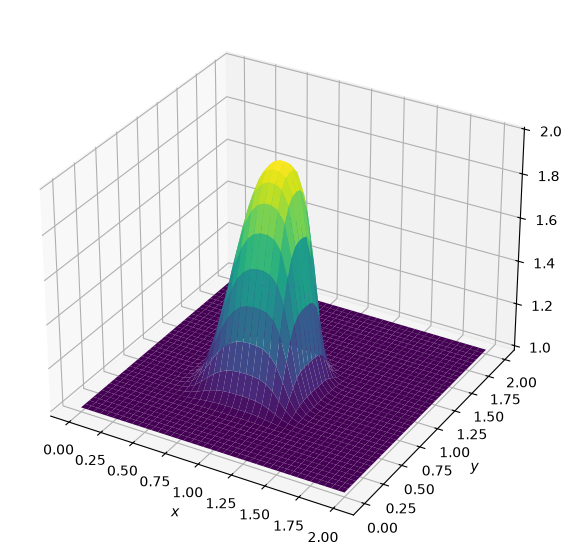

In [5]:
fig = plot.figure(figsize = (11,7), dpi=100)
ax = fig.add_subplot(111, projection='3d')
# The '111' means a grid of 1 row and 1 column and this subplot is the first one.

X, Y = np.meshgrid(x,y)

surf = ax.plot_surface(X,Y,u,cmap=cm.viridis)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$');

fig = plot.figure(figsize = (11,7), dpi=100)
ax = fig.add_subplot(111, projection='3d')
# The '111' means a grid of 1 row and 1 column and this subplot is the first one.
surf = ax.plot_surface(X,Y,v,cmap=cm.viridis)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$');